In [47]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

# cosmological parameters {Euclidean Universe: k = 0}
h = 0.71
Omega_m = 0.3
Omega_Lambda = 0.7
Omega_r = 0
# 1 - Omega_m = Omega_Lambda

# Define constants
H0 = 100*h  # Hubble constant in km/s/Mpc
c = 299792.458  # Speed of light in km/s

In [48]:
import os

# every sampler cell below checks this directory for a saved chain first and
# loads it instead of re-running - restarting the kernel no longer means
# re-sampling from scratch just to tweak a plot downstream.
# Delete the relevant .csv/.pkl/.h5 file here (or flip force_rerun=True in a
# sampler cell) if you actually want to redo a run from scratch.
cache_dir = "mcmc_cache_2param"
os.makedirs(cache_dir, exist_ok=True)

## Distances vs Redshift

In [49]:
# Hubble parameter H(z) for a flat matter + dark-energy universe
def H(z):
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda) #+ Omega_r * (1 + z)**4

# integrand c/H(z) for the comoving-distance integral
def integrand(z):
    return c / H(z)

# comoving distance: integral of c/H(z) dz from 0 to z
def comoving_distance(z):
    D_c, err = integrate.quad(integrand, 0, z)
    return D_c

# angular-diameter distance
def angular_diameter_distance(z):
    return comoving_distance(z) / (1 + z)

# luminosity distance
def luminosity_distance(z):
    return comoving_distance(z) * (1 + z)

# proper (physical) distance at the time of emission
def physical_distance(z):
    return comoving_distance(z) / (1 + z)

In [50]:
# sanity check at a single redshift
z_test = 2

print(f"Comoving distance     at z={z_test}: {comoving_distance(z_test):.3f} Mpc")
print(f"Angular-diameter dist at z={z_test}: {angular_diameter_distance(z_test):.3f} Mpc")
print(f"Luminosity distance   at z={z_test}: {luminosity_distance(z_test):.3f} Mpc")
print(f"Physical distance     at z={z_test}: {physical_distance(z_test):.3f} Mpc")

Comoving distance     at z=2: 5106.906 Mpc
Angular-diameter dist at z=2: 1702.302 Mpc
Luminosity distance   at z=2: 15320.719 Mpc
Physical distance     at z=2: 1702.302 Mpc


In [51]:
# build a redshift grid: denser sampling at low-z, sparser at high-z
z_low = np.linspace(0.01, 0.1, 200)
z_mid = np.linspace(0.1, 1, 200)
z_high = np.linspace(1, 10, 200)
z_grid = np.concatenate((z_low, z_mid, z_high))

D_c_arr = np.array([comoving_distance(z) for z in z_grid])
D_A_arr = D_c_arr / (1 + z_grid)
D_L_arr = D_c_arr * (1 + z_grid)

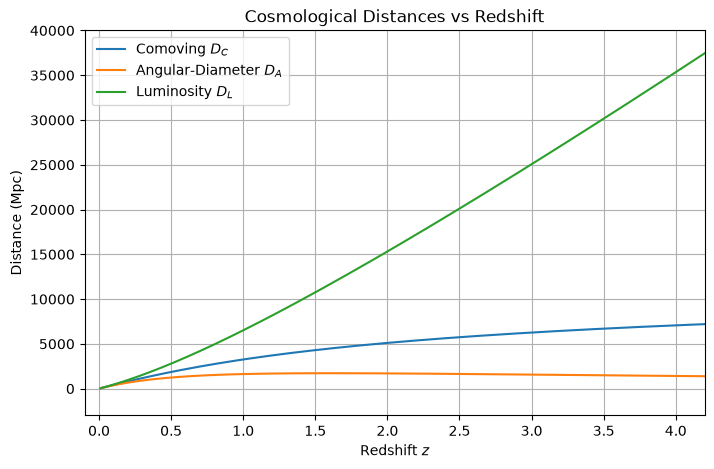

In [52]:
# linear-scale comparison plot
plt.figure(figsize=(8, 5))
plt.plot(z_grid, D_c_arr, label='Comoving $D_C$')
plt.plot(z_grid, D_A_arr, label='Angular-Diameter $D_A$')
plt.plot(z_grid, D_L_arr, label='Luminosity $D_L$')

plt.xlabel('Redshift $z$')
plt.ylabel('Distance (Mpc)')
plt.xlim(-0.1, 4.2)
plt.ylim(-3000, 40000)
plt.title('Cosmological Distances vs Redshift')
plt.legend()
plt.grid(True)
plt.show()

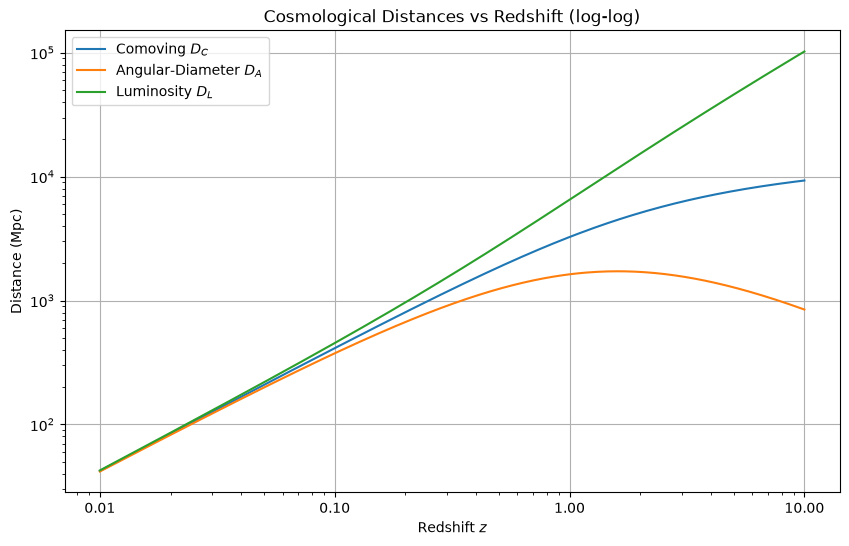

In [53]:
# same comparison on a log-log scale to see the full z-range
plt.figure(figsize=(10, 6))
plt.plot(z_grid, D_c_arr, label='Comoving $D_C$')
plt.plot(z_grid, D_A_arr, label='Angular-Diameter $D_A$')
plt.plot(z_grid, D_L_arr, label='Luminosity $D_L$')

plt.xlabel('Redshift $z$')
plt.ylabel('Distance (Mpc)')
plt.title('Cosmological Distances vs Redshift (log-log)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.set_xticks([0.01, 0.1, 1, 10])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
plt.show()

## Distance Modulus from Luminosity Distance

In [54]:
# distance modulus mu = m - M = 5*log10(D_L[pc]) - 5 = 5*log10(D_L[Mpc]) + 25
def distance_modulus(z):
    D_L = luminosity_distance(z)
    return 5 * np.log10(D_L) + 25

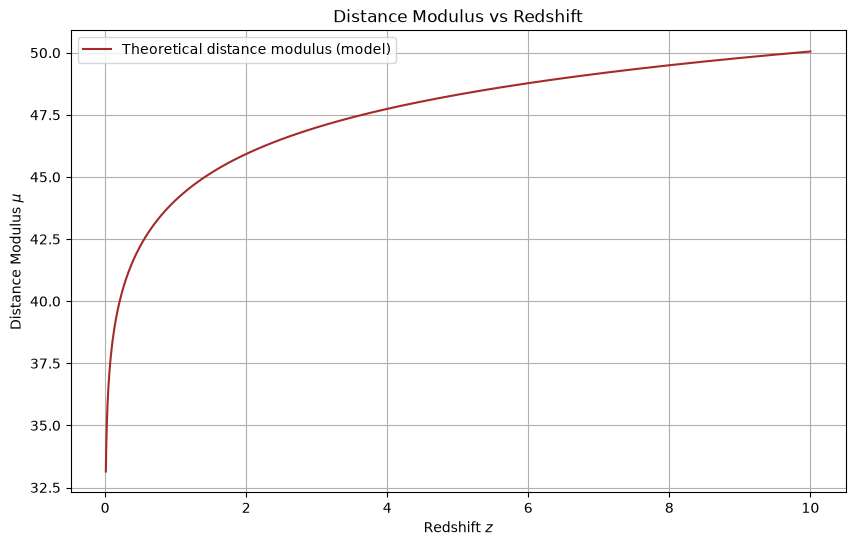

In [55]:
# distance modulus curve over the same redshift grid
mu_grid = np.array([distance_modulus(z) for z in z_grid])

plt.figure(figsize=(10, 6))
plt.plot(z_grid, mu_grid, c='brown', label='Theoretical distance modulus (model)')

plt.xlabel('Redshift $z$')
plt.ylabel(r'Distance Modulus $\mu$')
plt.title('Distance Modulus vs Redshift')
plt.grid()
plt.legend()
plt.show()

## Pantheon Supernova Data

The Pantheon compilation (Scolnic et al. 2018) contains 1048 Type Ia supernovae. Relevant columns used here:

- **#name** — SN identifier (e.g. survey/name of the supernova)
- **zcmb** — redshift of the host galaxy corrected to the CMB rest frame (used as the "true" cosmological redshift)
- **zhel** — heliocentric redshift (as observed, uncorrected for our motion relative to the CMB)
- **dz** — uncertainty on the redshift
- **mb** — apparent peak magnitude of the SN in the B-band, corrected via the SALT2 light-curve fit (standardizable candle magnitude)
- **dmb** — uncertainty on `mb`
- **dist_mod** — derived distance modulus, $\mu = m_B - M$, using an absolute magnitude $M = -19.35$ for a Type Ia SN standard candle

In [56]:
# load the pre-processed csv if it exists, otherwise build it from the raw Excel file
sn_data_path = "../Pantheon_SNdata.csv"
raw_excel_path = "../Pantheon - Scolnic SNe 1A 1048 z-asc 27May'19 (2).xlsx"

try:
    sn_df = pd.read_csv(sn_data_path)
    if 'dist_mod' not in sn_df.columns:
        sn_df['dist_mod'] = sn_df['mb'] + 19.35  # mu = m - M, M = -19.35
        sn_df.to_csv(sn_data_path, index=False)

except FileNotFoundError:
    sn_df = pd.read_excel(raw_excel_path)
    sn_df.columns = sn_df.iloc[0]
    sn_df = sn_df[1:].reset_index(drop=True)
    sn_df['dist_mod'] = sn_df['mb'] + 19.35
    sn_df.to_csv(sn_data_path, index=False)

sn_df.head()

,#name,zcmb,zhel,dz,mb,dmb,dist_mod
0,2002cr,0.01012,0.01012,0,13.90745,0.19825,33.25745
1,2002dp,0.01038,0.01038,0,14.04960,0.20480,33.39960
2,2009an,0.01043,0.01043,0,13.92480,0.20035,33.27480
3,2006bh,0.01082,0.01082,0,14.00860,0.18445,33.35860
4,1998dk,0.01209,0.01209,0,13.97910,0.19140,33.32910


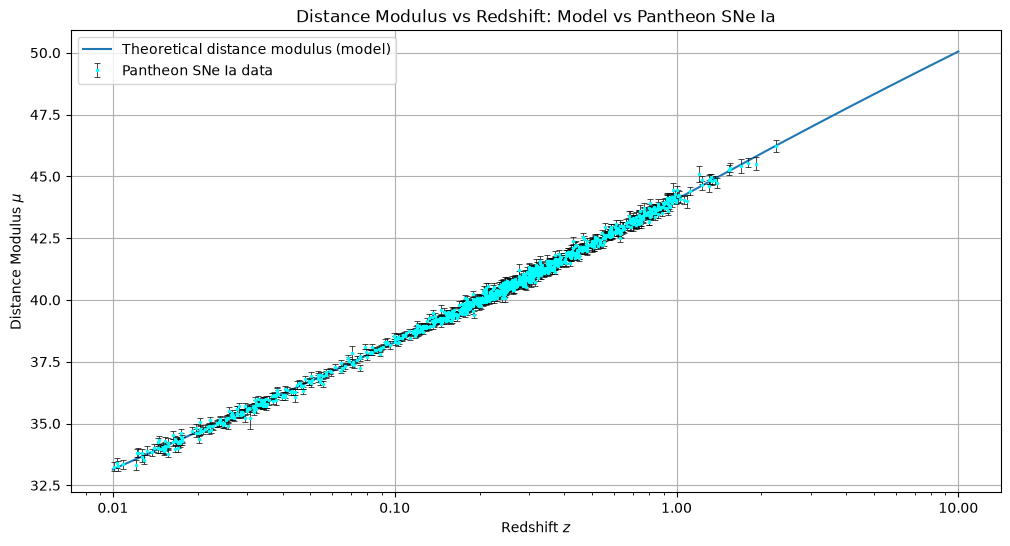

In [57]:
# overlay the Pantheon SN data on the theoretical distance-modulus curve
plt.figure(figsize=(12, 6))
plt.plot(z_grid, mu_grid, label='Theoretical distance modulus (model)')
plt.errorbar(sn_df['zcmb'], sn_df['dist_mod'], yerr=sn_df['dmb'],
             fmt='o', mfc='cyan', mec='cyan', ms=1.5,
             ecolor='black', capsize=2.5, capthick=0.5, elinewidth=0.5,
             label='Pantheon SNe Ia data')

plt.xlabel('Redshift $z$')
plt.ylabel(r'Distance Modulus $\mu$')
plt.title('Distance Modulus vs Redshift: Model vs Pantheon SNe Ia')
plt.grid()
plt.legend()

plt.xscale('log')
ax = plt.gca()
ax.set_xticks([0.01, 0.1, 1, 10])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.show()

## Chi-Squared Goodness of Fit

In [58]:
# chi-squared statistic comparing observed vs theoretical distance modulus
def chi_squared(observed, theoretical, error):
    observed = np.array(observed)
    theoretical = np.array(theoretical)
    error = np.array(error)
    return np.sum(((observed - theoretical) / error) ** 2)

In [59]:
# evaluate chi-squared for the Pantheon data against the current model parameters
theoretical_mu = [distance_modulus(z) for z in sn_df['zcmb']]
chi_sq_value = chi_squared(sn_df['dist_mod'], theoretical_mu, sn_df['dmb'])

print(f'Chi-squared @ H0={H0}, Omega_m={Omega_m}: {chi_sq_value:.3f}')

Chi-squared @ H0=71.0, Omega_m=0.3: 1097.867


# Parameter Estimation: Metropolis-Hastings MCMC

Constrain $\Omega_m$ and $H_0$ by minimizing $\chi^2$ between the Pantheon distance moduli and the model prediction, using a random-walk Metropolis-Hastings sampler.

In [60]:
# model distance modulus as an explicit function of (H0, omega_m) for sampling
def hubble_param(z, H0_val, omega_m_val):
    return H0_val * np.sqrt(omega_m_val * (1 + z)**3 + (1 - omega_m_val))

def dl_integrand(z, H0_val, omega_m_val):
    return c / hubble_param(z, H0_val, omega_m_val)

def model_distance_modulus(z, H0_val, omega_m_val):
    D_c, err = integrate.quad(dl_integrand, 0, z, args=(H0_val, omega_m_val))
    D_L = D_c * (1 + z)
    return 5 * np.log10(D_L) + 25

def log_likelihood_chi2(H0_val, omega_m_val):
    mu_model = [model_distance_modulus(z, H0_val, omega_m_val) for z in sn_df['zcmb']]
    return chi_squared(sn_df['dist_mod'], mu_model, sn_df['dmb'])

In [61]:
# propose a new (omega_m, H0) point via a Gaussian random walk, rejecting steps outside the prior box
def propose_step(omega_m_prev, H0_prev, step_omega_m, step_H0, omega_m_bounds, H0_bounds):
    omega_m_new = omega_m_prev + step_omega_m * np.random.normal(0, 1)
    H0_new = H0_prev + step_H0 * np.random.normal(0, 1)
    if omega_m_bounds[0] <= omega_m_new <= omega_m_bounds[1] and H0_bounds[0] <= H0_new <= H0_bounds[1]:
        return omega_m_new, H0_new
    return propose_step(omega_m_prev, H0_prev, step_omega_m, step_H0, omega_m_bounds, H0_bounds)

In [62]:
# MH sampler settings
mh_omega_m_bounds = [0.15, 0.45]
mh_H0_bounds = [55, 85]
mh_step_omega_m = 0.005
mh_step_H0 = 0.2
mh_n_iterations = 50000  # 100000

print(f'Omega_m bounds: {mh_omega_m_bounds}, step: {mh_step_omega_m}')
print(f'H0 bounds: {mh_H0_bounds}, step: {mh_step_H0}')
print(f'Iterations: {mh_n_iterations}')

Omega_m bounds: [0.15, 0.45], step: 0.005
H0 bounds: [55, 85], step: 0.2
Iterations: 50000


In [63]:
# run the Metropolis-Hastings chain (or load a cached one)
import json

mh_cache_path = os.path.join(cache_dir, "mh_chain.csv")
mh_meta_path = os.path.join(cache_dir, "mh_meta.json")
force_rerun = False   # set True to ignore the cache and re-sample

mh_current_settings = {
    'n_iterations': mh_n_iterations,
    'step_omega_m': mh_step_omega_m,
    'step_H0': mh_step_H0,
    'omega_m_bounds': mh_omega_m_bounds,
    'H0_bounds': mh_H0_bounds,
}

mh_cache_valid = False
if os.path.exists(mh_cache_path) and os.path.exists(mh_meta_path) and not force_rerun:
    with open(mh_meta_path) as f:
        mh_cached_settings = json.load(f)
    mh_cache_valid = (mh_cached_settings == mh_current_settings)
    if not mh_cache_valid:
        print(f"Cache found but settings changed - re-running.")
        print(f"  cached:  {mh_cached_settings}")
        print(f"  current: {mh_current_settings}")

if mh_cache_valid:
    mh_chain = pd.read_csv(mh_cache_path)
    n_accepted = len(mh_chain)   # only accepted steps get appended, so this is exact
    print(f"Loaded cached MH chain from {mh_cache_path} ({len(mh_chain)} accepted samples)")

else:
    mh_chain = pd.DataFrame(columns=['Omega_m', 'H0', 'Chi_sq', 'Type'])

    omega_m_curr = np.random.uniform(*mh_omega_m_bounds)
    H0_curr = np.random.uniform(*mh_H0_bounds)
    chi2_curr = log_likelihood_chi2(H0_curr, omega_m_curr)
    print("Starting point (omega_m, H0):", omega_m_curr, H0_curr)
    print("Starting chi-squared:", chi2_curr, '\n')

    n_accepted = 0
    for n in range(mh_n_iterations):
        omega_m_prop, H0_prop = propose_step(omega_m_curr, H0_curr, mh_step_omega_m, mh_step_H0,
                                              mh_omega_m_bounds, mh_H0_bounds)
        chi2_prop = log_likelihood_chi2(H0_prop, omega_m_prop)

        if chi2_prop <= chi2_curr:
            omega_m_curr, H0_curr, chi2_curr = omega_m_prop, H0_prop, chi2_prop
            mh_chain.loc[len(mh_chain)] = [omega_m_curr, H0_curr, chi2_curr, 1]
            n_accepted += 1
        else:
            accept_prob = np.exp(-(chi2_prop - chi2_curr) / 2)
            if accept_prob > np.random.uniform(0, 1):
                omega_m_curr, H0_curr, chi2_curr = omega_m_prop, H0_prop, chi2_prop
                mh_chain.loc[len(mh_chain)] = [omega_m_curr, H0_curr, chi2_curr, 2]
                n_accepted += 1

    print("Final (omega_m, H0):", omega_m_curr, H0_curr)
    print("Final chi-squared:", chi2_curr)
    print(f"Acceptance fraction: {n_accepted / mh_n_iterations:.3f}")

    mh_chain.to_csv(mh_cache_path, index=False)
    with open(mh_meta_path, "w") as f:
        json.dump(mh_current_settings, f)
    print(f"Saved MH chain to {mh_cache_path}")

Loaded cached MH chain from mcmc_cache_2param\mh_chain.csv (27068 accepted samples)


In [64]:
# trim burn-in: keep from the first sample within 10% of the final chi-squared
final_chi2 = mh_chain['Chi_sq'].iloc[-1]
burn_in_idx = mh_chain[mh_chain['Chi_sq'] < 1.1 * final_chi2].index[0]
mh_chain_trimmed = mh_chain.iloc[burn_in_idx:].reset_index(drop=True)

print(f"Burn-in cutoff index: {burn_in_idx}")
print(f"Samples retained: {len(mh_chain_trimmed)} / {len(mh_chain)}")
mh_chain_trimmed.head()

Burn-in cutoff index: 92
Samples retained: 26976 / 27068


,Omega_m,H0,Chi_sq,Type
0,0.167983,71.771596,1145.616771,1.0
1,0.170852,71.594474,1142.390090,1.0
2,0.176116,71.793403,1128.483908,1.0
3,0.178247,71.929212,1126.448923,1.0
4,0.176149,71.724427,1128.495200,2.0


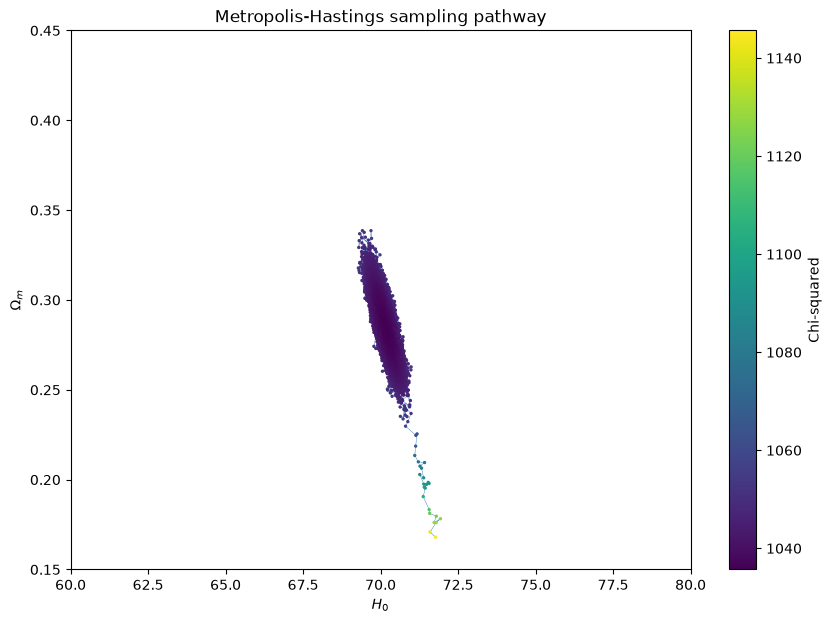

In [65]:
# MH sampling pathway in (H0, Omega_m) space, colored by chi-squared
plt.figure(figsize=(10, 7))
plt.plot(mh_chain_trimmed['H0'], mh_chain_trimmed['Omega_m'], linewidth=0.3, zorder=1)
sc = plt.scatter(mh_chain_trimmed['H0'], mh_chain_trimmed['Omega_m'],
                  c=mh_chain_trimmed['Chi_sq'], cmap='viridis', s=2, zorder=2)
plt.colorbar(sc, label='Chi-squared')
plt.xlabel('$H_0$')
plt.ylabel('$\\Omega_m$')
plt.title('Metropolis-Hastings sampling pathway')
plt.xlim(mh_H0_bounds[0] + 5, mh_H0_bounds[1] - 5)
plt.ylim(mh_omega_m_bounds[0], mh_omega_m_bounds[1])
plt.show()

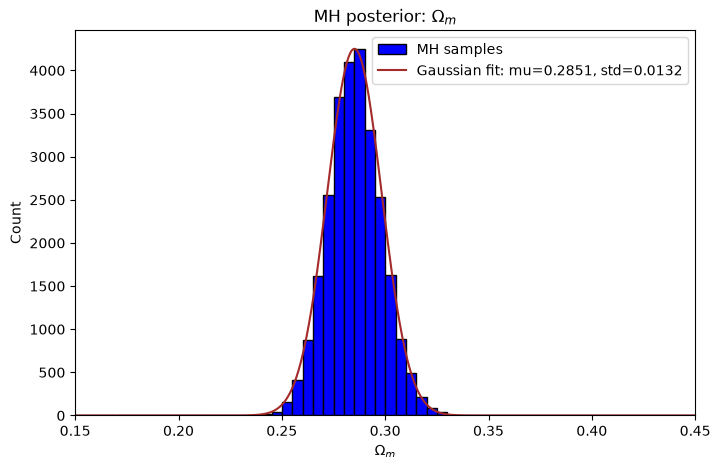

In [66]:
# Omega_m posterior histogram with Gaussian fit
bins_omega_m = np.linspace(mh_omega_m_bounds[0], mh_omega_m_bounds[1],
                            int((mh_omega_m_bounds[1] - mh_omega_m_bounds[0]) / mh_step_omega_m) + 1)

mh_mu_omega_m, mh_std_omega_m = norm.fit(mh_chain_trimmed['Omega_m'])
A_omega_m = 1 / (mh_std_omega_m * np.sqrt(2 * np.pi))

plt.figure(figsize=(8, 5))
counts, bins, _ = plt.hist(mh_chain_trimmed['Omega_m'], bins=bins_omega_m,
                            color='blue', edgecolor='black', label='MH samples')
x = np.linspace(mh_omega_m_bounds[0], mh_omega_m_bounds[1], 1000)
p = norm.pdf(x, mh_mu_omega_m, mh_std_omega_m)
plt.plot(x, p * counts.max() / A_omega_m, c='brown', linewidth=1.5,
         label=f'Gaussian fit: mu={mh_mu_omega_m:.4f}, std={mh_std_omega_m:.4f}')

plt.xlabel('$\\Omega_m$')
plt.ylabel('Count')
plt.xlim(mh_omega_m_bounds[0], mh_omega_m_bounds[1])
plt.title('MH posterior: $\\Omega_m$')
plt.legend()
plt.show()

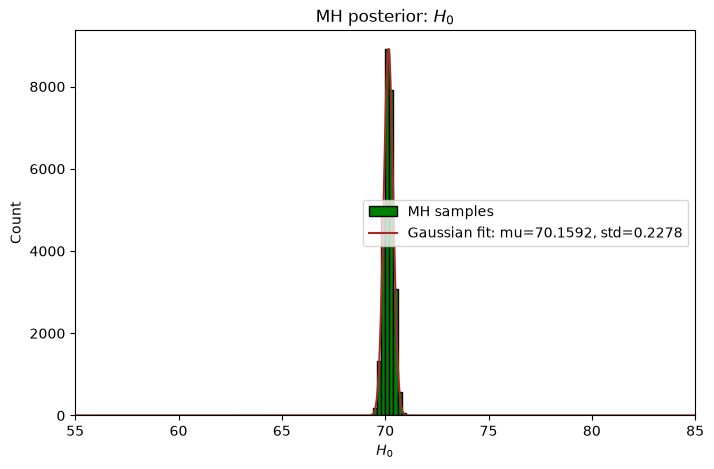

In [67]:
# H0 posterior histogram with Gaussian fit
bins_H0 = np.linspace(mh_H0_bounds[0], mh_H0_bounds[1],
                       int((mh_H0_bounds[1] - mh_H0_bounds[0]) / mh_step_H0) + 1)

mh_mu_H0, mh_std_H0 = norm.fit(mh_chain_trimmed['H0'])
A_H0 = 1 / (mh_std_H0 * np.sqrt(2 * np.pi))

plt.figure(figsize=(8, 5))
counts, bins, _ = plt.hist(mh_chain_trimmed['H0'], bins=bins_H0,
                            color='green', edgecolor='black', label='MH samples')
x = np.linspace(mh_H0_bounds[0], mh_H0_bounds[1], 1000)
p = norm.pdf(x, mh_mu_H0, mh_std_H0)
plt.plot(x, p * counts.max() / A_H0, c='brown', linewidth=1.5,
         label=f'Gaussian fit: mu={mh_mu_H0:.4f}, std={mh_std_H0:.4f}')

plt.xlabel('$H_0$')
plt.ylabel('Count')
plt.xlim(mh_H0_bounds[0], mh_H0_bounds[1])
plt.title('MH posterior: $H_0$')
plt.legend()
plt.show()

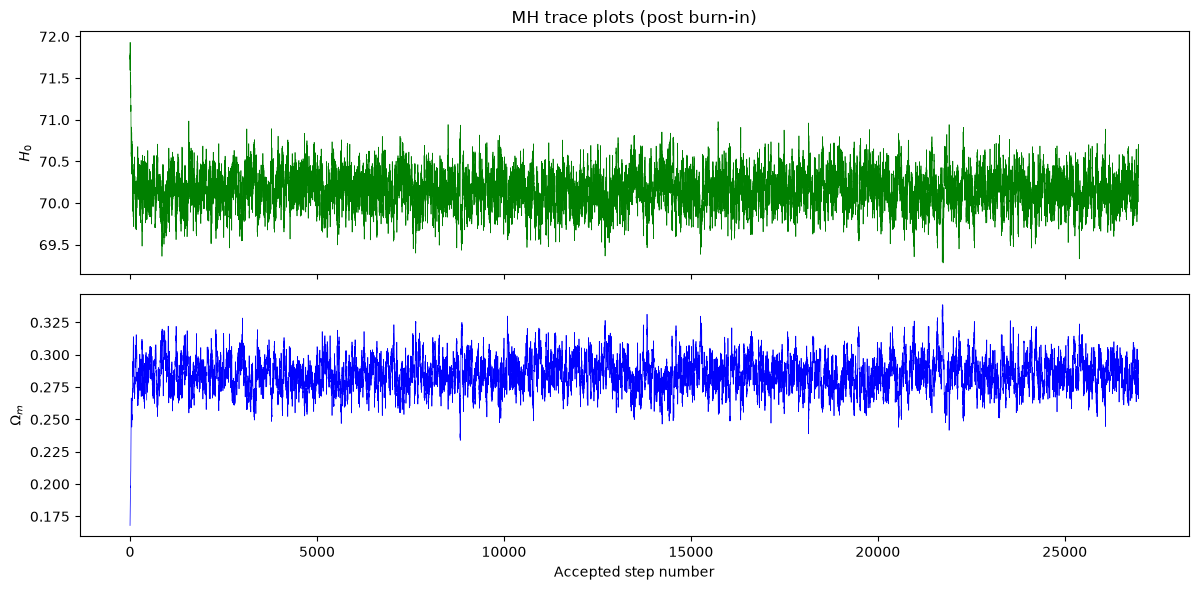

In [68]:
# trace plots to visually check mixing / convergence
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(mh_chain_trimmed['H0'], linewidth=0.5, color='green')
axes[0].set_ylabel('$H_0$')
axes[0].set_title('MH trace plots (post burn-in)')

axes[1].plot(mh_chain_trimmed['Omega_m'], linewidth=0.5, color='blue')
axes[1].set_ylabel('$\\Omega_m$')
axes[1].set_xlabel('Accepted step number')
plt.tight_layout()
plt.show()

# Parameter Estimation: emcee Affine-Invariant Ensemble Sampler

Same likelihood, sampled with `emcee`'s affine-invariant ensemble sampler instead of a single random-walk chain. Requires `pip install emcee` and (optionally) `corner`.

In [69]:
%pip install emcee
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:

import emcee
import time

# log-prior: flat/uniform within the same bounds used for the MH sampler
def log_prior(theta):
    omega_m_val, H0_val = theta
    if mh_omega_m_bounds[0] <= omega_m_val <= mh_omega_m_bounds[1] and \
       mh_H0_bounds[0] <= H0_val <= mh_H0_bounds[1]:
        return 0.0
    return -np.inf

# log-likelihood: -chi^2/2 for a Gaussian error model
def log_likelihood(theta):
    omega_m_val, H0_val = theta
    return -0.5 * log_likelihood_chi2(H0_val, omega_m_val)

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

In [71]:
%pip install h5py
%pip show h5py

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Name: h5py
Version: 3.16.0
Summary: Read and write HDF5 files from Python
Home-page: https://www.h5py.org/
Author: 
Author-email: Andrew Collette <andrew.collette@gmail.com>
License-Expression: BSD-3-Clause
Location: c:\Users\KISHOR\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [72]:
# ensemble sampler settings: walkers scattered in a tight ball around a starting guess
import json

n_dim = 2
n_walkers = 15
n_steps = 3300
n_burn = 300

emcee_backend_path = os.path.join(cache_dir, "emcee_chain.h5")   # requires: pip install h5py
emcee_meta_path = os.path.join(cache_dir, "emcee_meta.json")
force_rerun_emcee = False   # set True to ignore the cache and re-sample

emcee_current_settings = {'n_walkers': n_walkers, 'n_steps': n_steps, 'n_dim': n_dim}

emcee_cache_valid = False
if os.path.exists(emcee_backend_path) and os.path.exists(emcee_meta_path) and not force_rerun_emcee:
    with open(emcee_meta_path) as f:
        emcee_cached_settings = json.load(f)
    emcee_cache_valid = (emcee_cached_settings == emcee_current_settings)
    if not emcee_cache_valid:
        print(f"Cache found but settings changed - re-running.")
        print(f"  cached:  {emcee_cached_settings}")
        print(f"  current: {emcee_current_settings}")

backend = emcee.backends.HDFBackend(emcee_backend_path)

if emcee_cache_valid:
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, backend=backend)
    print(f"Loaded cached emcee chain from {emcee_backend_path} ({backend.iteration} steps)")

else:
    theta0 = np.array([0.3, 70.0])  # (omega_m, H0) initial guess
    spread = np.array([0.01, 0.5])
    initial_pos = theta0 + spread * np.random.randn(n_walkers, n_dim)

    backend.reset(n_walkers, n_dim)
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, backend=backend)

    start_time = time.time()
    sampler.run_mcmc(initial_pos, n_steps, progress=True)
    emcee_runtime = time.time() - start_time
    print(f"emcee runtime: {emcee_runtime:.2f} s")

    with open(emcee_meta_path, "w") as f:
        json.dump(emcee_current_settings, f)
    print(f"Saved emcee chain to {emcee_backend_path}")

print(f"Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")

Loaded cached emcee chain from mcmc_cache_2param\emcee_chain.h5 (3300 steps)
Mean acceptance fraction: 0.712


In [73]:
# discard burn-in and flatten walkers into a single sample set
emcee_flat_samples = sampler.get_chain(discard=n_burn, flat=True)
emcee_omega_m_samples = emcee_flat_samples[:, 0]
emcee_H0_samples = emcee_flat_samples[:, 1]

emcee_tau = sampler.get_autocorr_time(quiet=True)
print(f"Autocorrelation time (omega_m, H0): {emcee_tau}")
print(f"Effective independent samples: {len(emcee_flat_samples) / np.mean(emcee_tau):.0f}")

Autocorrelation time (omega_m, H0): [30.95769685 28.79217861]
Effective independent samples: 1506


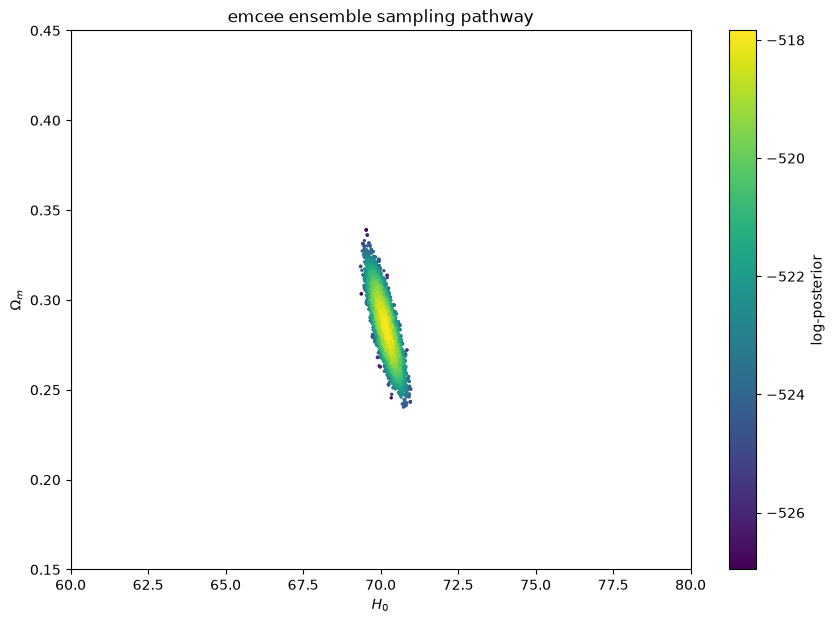

In [74]:
# emcee sampling pathway in (H0, Omega_m) space, colored by log-posterior
emcee_logpost = sampler.get_log_prob(discard=n_burn, flat=True)

plt.figure(figsize=(10, 7))
sc = plt.scatter(emcee_H0_samples, emcee_omega_m_samples, c=emcee_logpost, cmap='viridis', s=2)
plt.colorbar(sc, label='log-posterior')
plt.xlabel('$H_0$')
plt.ylabel('$\\Omega_m$')
plt.title('emcee ensemble sampling pathway')
plt.xlim(mh_H0_bounds[0] + 5, mh_H0_bounds[1] - 5)
plt.ylim(mh_omega_m_bounds[0], mh_omega_m_bounds[1])
plt.show()

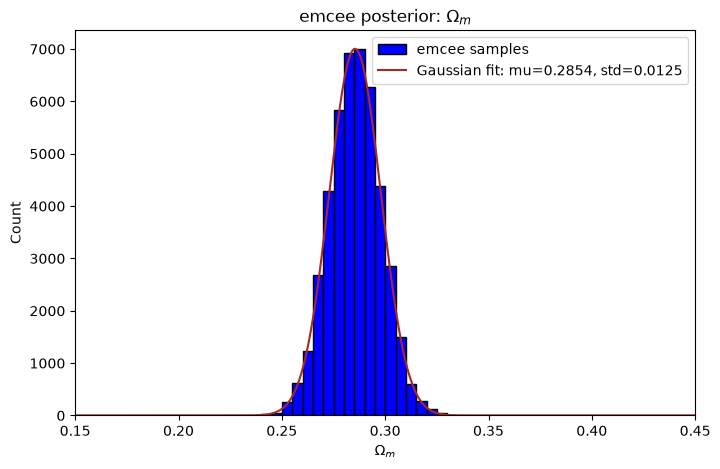

In [75]:
# Omega_m posterior histogram with Gaussian fit (emcee)
emcee_mu_omega_m, emcee_std_omega_m = norm.fit(emcee_omega_m_samples)
A_omega_m_e = 1 / (emcee_std_omega_m * np.sqrt(2 * np.pi))

plt.figure(figsize=(8, 5))
counts, bins, _ = plt.hist(emcee_omega_m_samples, bins=bins_omega_m,
                            color='blue', edgecolor='black', label='emcee samples')
x = np.linspace(mh_omega_m_bounds[0], mh_omega_m_bounds[1], 1000)
p = norm.pdf(x, emcee_mu_omega_m, emcee_std_omega_m)
plt.plot(x, p * counts.max() / A_omega_m_e, c='brown', linewidth=1.5,
         label=f'Gaussian fit: mu={emcee_mu_omega_m:.4f}, std={emcee_std_omega_m:.4f}')

plt.xlabel('$\\Omega_m$')
plt.ylabel('Count')
plt.xlim(mh_omega_m_bounds[0], mh_omega_m_bounds[1])
plt.title('emcee posterior: $\\Omega_m$')
plt.legend()
plt.show()

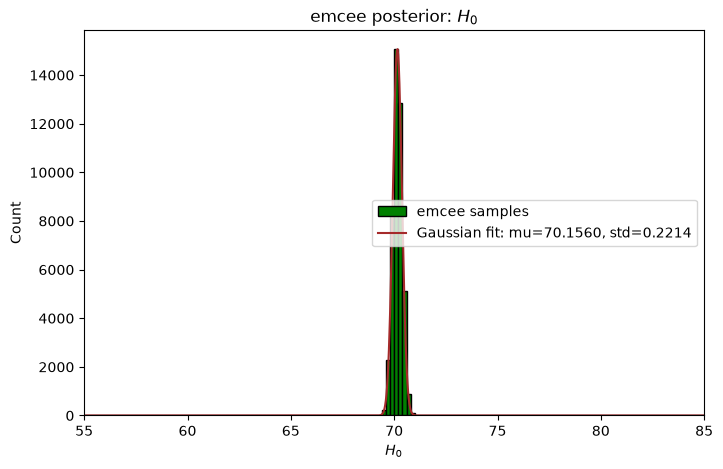

In [76]:
# H0 posterior histogram with Gaussian fit (emcee)
emcee_mu_H0, emcee_std_H0 = norm.fit(emcee_H0_samples)
A_H0_e = 1 / (emcee_std_H0 * np.sqrt(2 * np.pi))

plt.figure(figsize=(8, 5))
counts, bins, _ = plt.hist(emcee_H0_samples, bins=bins_H0,
                            color='green', edgecolor='black', label='emcee samples')
x = np.linspace(mh_H0_bounds[0], mh_H0_bounds[1], 1000)
p = norm.pdf(x, emcee_mu_H0, emcee_std_H0)
plt.plot(x, p * counts.max() / A_H0_e, c='brown', linewidth=1.5,
         label=f'Gaussian fit: mu={emcee_mu_H0:.4f}, std={emcee_std_H0:.4f}')

plt.xlabel('$H_0$')
plt.ylabel('Count')
plt.xlim(mh_H0_bounds[0], mh_H0_bounds[1])
plt.title('emcee posterior: $H_0$')
plt.legend()
plt.show()

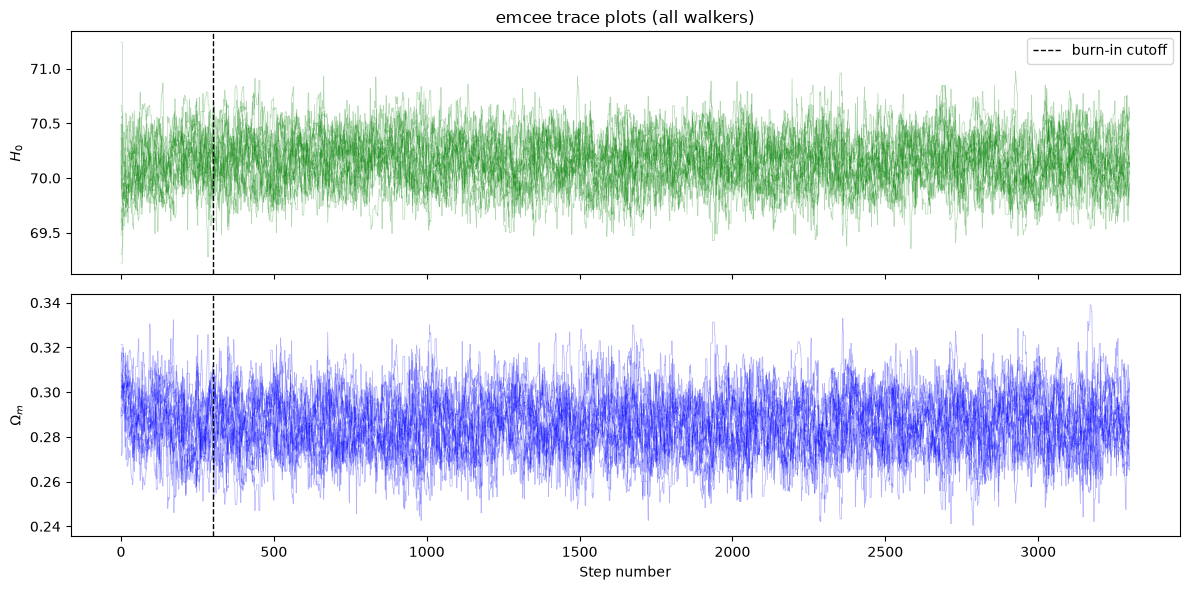

In [77]:
# trace plots for all walkers (before burn-in removal) to check convergence visually
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
full_chain = sampler.get_chain()

axes[0].plot(full_chain[:, :, 1], color='green', alpha=0.3, linewidth=0.5)
axes[0].axvline(n_burn, color='black', linestyle='--', linewidth=1, label='burn-in cutoff')
axes[0].set_ylabel('$H_0$')
axes[0].set_title('emcee trace plots (all walkers)')
axes[0].legend()

axes[1].plot(full_chain[:, :, 0], color='blue', alpha=0.3, linewidth=0.5)
axes[1].axvline(n_burn, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('$\\Omega_m$')
axes[1].set_xlabel('Step number')
plt.tight_layout()
plt.show()

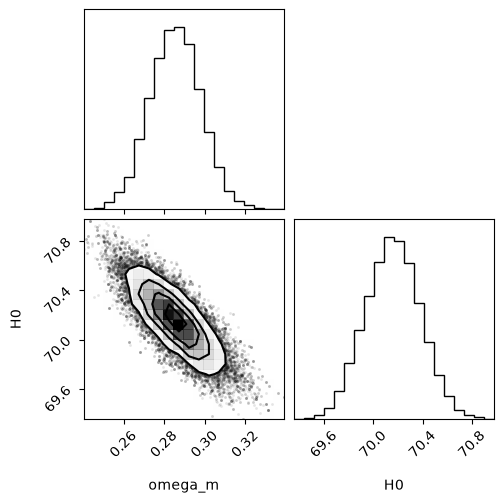

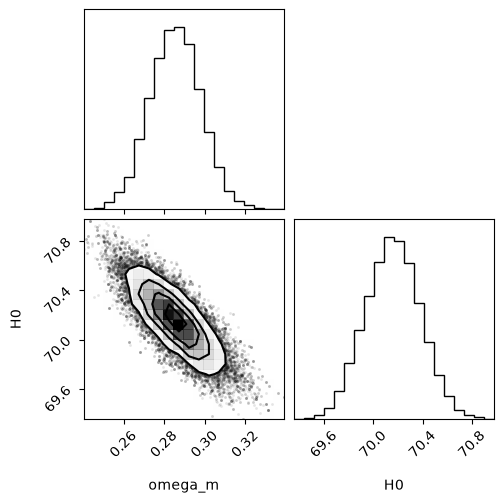

In [78]:
import corner

samples_dict = emcee_flat_samples[:, :2]
corner.corner(samples_dict, labels=["omega_m", "H0"],)

# Comparison: Metropolis-Hastings vs emcee

In [79]:
# build a quantitative comparison table from the two runs above
mh_eff_samples = len(mh_chain_trimmed)  # MH has no built-in independence measure; raw accepted count
emcee_eff_samples = len(emcee_flat_samples) / np.mean(emcee_tau)
mh_accept_frac = n_accepted / mh_n_iterations
emcee_accept_frac = np.mean(sampler.acceptance_fraction)

comparison_table = pd.DataFrame({
    'Metric': [
        'H0 estimate (mean)',
        'H0 std',
        'Omega_m estimate (mean)',
        'Omega_m std',
        'Total samples drawn',
        'Acceptance fraction',
        'Effective independent samples',
        'Needs manual step-size tuning',
        'Parallelizable across chains',
        'Built-in convergence diagnostics',
    ],
    'Metropolis-Hastings': [
        f'{mh_mu_H0:.3f}', f'{mh_std_H0:.3f}',
        f'{mh_mu_omega_m:.4f}', f'{mh_std_omega_m:.4f}',
        mh_n_iterations, f'{mh_accept_frac:.3f}',
        mh_eff_samples, 'Yes (step, bounds)', 'No (single chain)', 'No (manual burn-in cut)',
    ],
    'emcee (ensemble)': [
        f'{emcee_mu_H0:.3f}', f'{emcee_std_H0:.3f}',
        f'{emcee_mu_omega_m:.4f}', f'{emcee_std_omega_m:.4f}',
        n_walkers * n_steps, f'{emcee_accept_frac:.3f}',
        f'{emcee_eff_samples:.0f}', 'No (self-tuning)', 'Yes (walkers)', 'Yes (autocorr time tau)',
    ],
})

comparison_table

,Metric,Metropolis-Hastings,emcee (ensemble)
0,H0 estimate (mean),70.159,70.156
1,H0 std,0.228,0.221
2,Omega_m estimate (mean),0.2851,0.2854
3,Omega_m std,0.0132,0.0125
4,Total samples drawn,50000,49500
5,Acceptance fraction,0.541,0.712
6,Effective independent samples,26976,1506
7,Needs manual step-size tuning,"Yes (step, bounds)",No (self-tuning)
8,Parallelizable across chains,No (single chain),Yes (walkers)
9,Built-in convergence diagnostics,No (manual burn-in cut),Yes (autocorr time tau)


**How to read the table:**

- **Estimate & std** — both should agree if both chains converged; a much larger std usually means the chain is still noisy/under-sampled, not necessarily "wrong."
- **Acceptance fraction** — the classic MH rule of thumb is ~20-40% for good mixing in low dimensions; emcee's ensemble moves are designed to self-tune into a healthy range (~0.2-0.5) without hand-picking a step size.
- **Effective independent samples** is the better indicator than raw draw count for "how much did we actually learn" — MH samples are serially correlated (no autocorrelation-time estimate here), while emcee's `get_autocorr_time` gives a direct, quantitative measure of this and lets you compute effective sample size properly.
- **Convergence diagnostics** — emcee provides autocorrelation time out of the box; the MH implementation above only has a heuristic burn-in cut based on chi-squared proximity, which is weaker evidence of convergence.

**Bottom line:** for this 2-parameter (H0, Ωm) fit, emcee should give a comparably accurate central estimate with far less manual tuning, built-in convergence diagnostics (autocorrelation time), and a principled effective-sample-size number — making it the better-justified choice, even though plain MH can reach a similar answer given enough iterations and well-tuned step sizes.

# Adaptive MCMC (Adaptive Metropolis, Haario et al. 2001)

The plain MH sampler above used a fixed, hand-picked, diagonal step size (`mh_step_omega_m`, `mh_step_H0`) — i.e. it implicitly assumed the two parameters are uncorrelated. The pathway plot shows they aren't.

**Adaptive Metropolis (AM)** fixes this in two stages:

1. **Seed the proposal with a real covariance matrix** instead of a diagonal guess — estimated here from the pilot MH chain that already ran (`mh_chain_trimmed`).
2. **Keep updating that covariance matrix as the adaptive chain runs**, using the chain's own accumulated samples, following Haario's scaling

$$C_t = s_d \cdot \text{Cov}(\theta_0, \dots, \theta_t) + s_d\,\epsilon I_d, \qquad s_d = \frac{2.4^2}{d}$$

which is the scale that makes the proposal's acceptance rate near-optimal for a Gaussian-like target in $d$ dimensions. This means the proposal shape "learns" the tilt/elongation of the posterior as it runs, instead of that tilt being invisible to the sampler the way it is in plain MH.

In [80]:
# pilot covariance matrix, estimated from the completed plain-MH chain
pilot_samples = mh_chain_trimmed[['Omega_m', 'H0']].to_numpy()
pilot_cov = np.cov(pilot_samples, rowvar=False)
pilot_corr = np.corrcoef(pilot_samples, rowvar=False)

print("Pilot covariance matrix (Omega_m, H0):")
print(pilot_cov)
print("\nPilot correlation matrix:")
print(pilot_corr)
print(f"\nOmega_m-H0 correlation coefficient: {pilot_corr[0, 1]:.3f}")

Pilot covariance matrix (Omega_m, H0):
[[ 0.00017433 -0.00240086]
 [-0.00240086  0.0518731 ]]

Pilot correlation matrix:
[[ 1.         -0.79838157]
 [-0.79838157  1.        ]]

Omega_m-H0 correlation coefficient: -0.798


## Adaptive MCMC Settings

`d = 2` free parameters. Haario's scaling constant $s_d = 2.4^2/d$ makes the proposal's
acceptance rate land near the theoretically optimal range for a roughly-Gaussian target.
`epsilon` is a tiny regularizer added to the diagonal so the proposal covariance never
becomes singular (this can happen if the chain's empirical covariance briefly collapses,
e.g. right after getting stuck at a single point for a while).

In [81]:
d = 2                          # (omega_m, H0)
sd = (2.4**2) / d              # Haario's optimal scaling constant
epsilon = 1e-8                 # covariance regularizer

adapt_start = 400               # start adapting the covariance after this many iterations
adapt_interval = 150             # recompute the covariance every this many iterations
am_n_iterations = 50000

initial_theta = pilot_samples[-1].copy()   # start where the pilot MH chain ended
initial_cov = sd * pilot_cov + sd * epsilon * np.eye(d)   # seed proposal from pilot covariance

def in_bounds_2p(theta):
    omega_m_val, H0_val = theta
    return (mh_omega_m_bounds[0] <= omega_m_val <= mh_omega_m_bounds[1] and
            mh_H0_bounds[0] <= H0_val <= mh_H0_bounds[1])

print(f"d={d}, s_d={sd:.3f}")
print(f"Starting point (omega_m, H0): {initial_theta}")
print("Initial (seeded) proposal covariance:")
print(initial_cov)

d=2, s_d=2.880
Starting point (omega_m, H0): [ 0.28175085 70.57325478]
Initial (seeded) proposal covariance:
[[ 0.0005021  -0.00691447]
 [-0.00691447  0.14939455]]


## Run the Adaptive Metropolis Chain

Standard MH accept/reject step, but the proposal covariance `proposal_cov` is periodically
recomputed from the *chain's own accumulated samples* (including the pilot samples, so it
starts already informed) every `adapt_interval` steps once past `adapt_start`. This is the
non-recursive form of Haario's Adaptive Metropolis — mathematically equivalent to the
recursive update formula, just computed as a batch recalculation for clarity instead of an
incremental mean/covariance update.

In [82]:
# run the Adaptive Metropolis chain (or load a cached one)
import pickle
import json

am_cache_path = os.path.join(cache_dir, "am_chain.csv")
am_cov_cache_path = os.path.join(cache_dir, "am_cov_snapshots.pkl")
am_meta_path = os.path.join(cache_dir, "am_meta.json")
force_rerun_am = False   # set True to ignore the cache and re-sample

am_current_settings = {
    'n_iterations': am_n_iterations,
    'adapt_start': adapt_start,
    'adapt_interval': adapt_interval,
    'd': d,
}

am_cache_valid = False
if (os.path.exists(am_cache_path) and os.path.exists(am_cov_cache_path)
        and os.path.exists(am_meta_path) and not force_rerun_am):
    with open(am_meta_path) as f:
        am_cached_settings = json.load(f)
    am_cache_valid = (am_cached_settings == am_current_settings)
    if not am_cache_valid:
        print(f"Cache found but settings changed - re-running.")
        print(f"  cached:  {am_cached_settings}")
        print(f"  current: {am_current_settings}")

if am_cache_valid:
    am_chain = pd.read_csv(am_cache_path)
    with open(am_cov_cache_path, "rb") as f:
        cov_snapshots = pickle.load(f)
    n_accepted_am = int(am_chain['Accepted'].sum())
    proposal_cov = cov_snapshots[-1][1] if cov_snapshots else initial_cov
    print(f"Loaded cached AM chain from {am_cache_path} ({len(am_chain)} samples)")

else:
    history = list(pilot_samples)  # list of (omega_m, H0) arrays

    am_samples = np.zeros((am_n_iterations, d))
    am_chi2 = np.zeros(am_n_iterations)
    am_accepted = np.zeros(am_n_iterations, dtype=bool)
    cov_snapshots = []  # (iteration, covariance matrix, correlation coefficient) each time we adapt

    theta_curr = initial_theta.copy()
    chi2_curr = log_likelihood_chi2(theta_curr[1], theta_curr[0])
    proposal_cov = initial_cov.copy()

    n_accepted_am = 0
    for t in range(am_n_iterations):
        theta_prop = np.random.multivariate_normal(theta_curr, proposal_cov)

        if in_bounds_2p(theta_prop):
            chi2_prop = log_likelihood_chi2(theta_prop[1], theta_prop[0])
            accept_prob = min(1.0, np.exp(-(chi2_prop - chi2_curr) / 2))
        else:
            accept_prob = 0.0
            chi2_prop = chi2_curr

        if np.random.uniform(0, 1) < accept_prob:
            theta_curr, chi2_curr = theta_prop, chi2_prop
            n_accepted_am += 1
            am_accepted[t] = True

        am_samples[t] = theta_curr
        am_chi2[t] = chi2_curr
        history.append(theta_curr.copy())

        # --- covariance update step ---
        if t >= adapt_start and t % adapt_interval == 0:
            empirical_cov = np.cov(np.array(history), rowvar=False)
            proposal_cov = sd * empirical_cov + sd * epsilon * np.eye(d)
            empirical_corr = np.corrcoef(np.array(history), rowvar=False)
            cov_snapshots.append((t, empirical_cov.copy(), empirical_corr[0, 1]))

    print(f"Adaptive MCMC acceptance fraction: {n_accepted_am / am_n_iterations:.3f}")
    print(f"Number of covariance updates performed: {len(cov_snapshots)}")
    print("\nFinal adapted proposal covariance:")
    print(proposal_cov)

    am_chain = pd.DataFrame(am_samples, columns=['Omega_m', 'H0'])
    am_chain['Chi_sq'] = am_chi2
    am_chain['Accepted'] = am_accepted
    am_chain.to_csv(am_cache_path, index=False)
    with open(am_cov_cache_path, "wb") as f:
        pickle.dump(cov_snapshots, f)
    with open(am_meta_path, "w") as f:
        json.dump(am_current_settings, f)
    print(f"Saved AM chain to {am_cache_path} and covariance snapshots to {am_cov_cache_path}")

Loaded cached AM chain from mcmc_cache_2param\am_chain.csv (50000 samples)


In [83]:
# drop the (short) pre-adaptation burn-in (am_chain is already built, cached or fresh)
am_chain_trimmed = am_chain.iloc[adapt_start:].reset_index(drop=True)
print(f"Samples retained: {len(am_chain_trimmed)} / {len(am_chain)}")
am_chain_trimmed.head()

Samples retained: 49600 / 50000


,Omega_m,H0,Chi_sq,Accepted
0,0.273594,70.213923,1037.063573,False
1,0.273594,70.213923,1037.063573,False
2,0.273594,70.213923,1037.063573,False
3,0.273594,70.213923,1037.063573,False
4,0.277750,70.281371,1036.005962,True


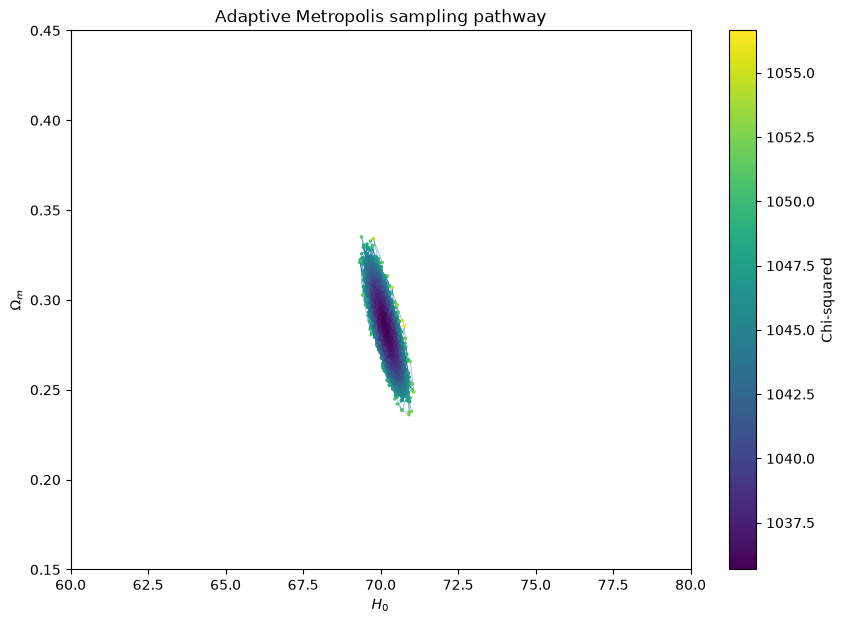

In [84]:
# adaptive MCMC sampling pathway, colored by chi-squared
plt.figure(figsize=(10, 7))
plt.plot(am_chain_trimmed['H0'], am_chain_trimmed['Omega_m'], linewidth=0.3, zorder=1)
sc = plt.scatter(am_chain_trimmed['H0'], am_chain_trimmed['Omega_m'],
                  c=am_chain_trimmed['Chi_sq'], cmap='viridis', s=2, zorder=2)
plt.colorbar(sc, label='Chi-squared')
plt.xlabel('$H_0$')
plt.ylabel('$\\Omega_m$')
plt.title('Adaptive Metropolis sampling pathway')
plt.xlim(mh_H0_bounds[0] + 5, mh_H0_bounds[1] - 5)
plt.ylim(mh_omega_m_bounds[0], mh_omega_m_bounds[1])
plt.show()

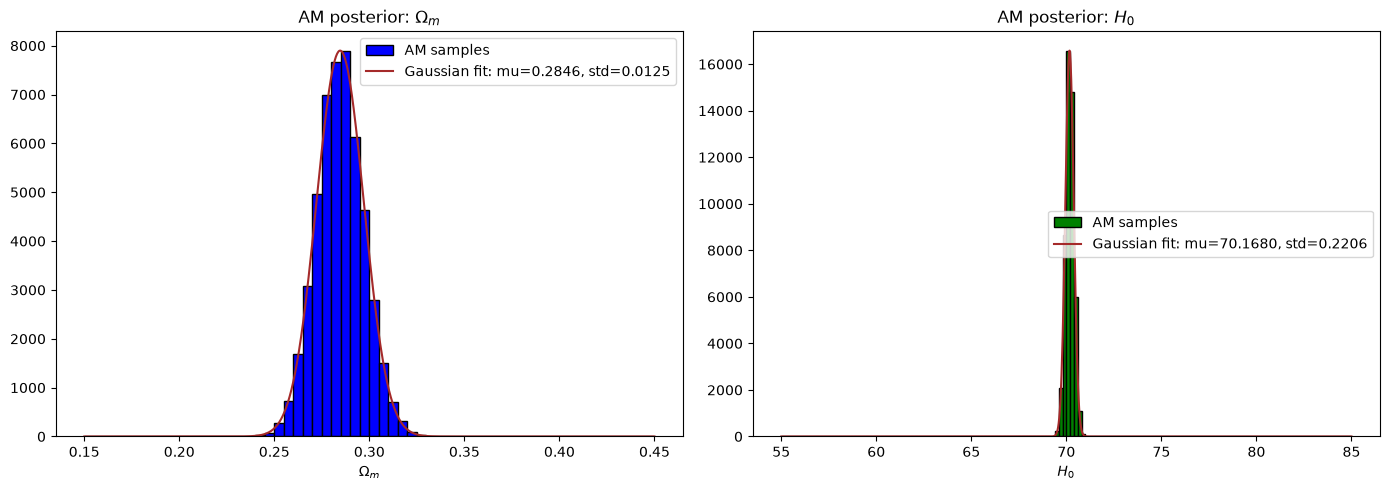

In [85]:
# posterior histograms with Gaussian fits (adaptive MCMC)
am_mu_omega_m, am_std_omega_m = norm.fit(am_chain_trimmed['Omega_m'])
am_mu_H0, am_std_H0 = norm.fit(am_chain_trimmed['H0'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts0, bins0, _ = axes[0].hist(am_chain_trimmed['Omega_m'], bins=bins_omega_m,
                                  color='blue', edgecolor='black', label='AM samples')
x0 = np.linspace(mh_omega_m_bounds[0], mh_omega_m_bounds[1], 1000)
p0 = norm.pdf(x0, am_mu_omega_m, am_std_omega_m)
axes[0].plot(x0, p0 * counts0.max() / p0.max(), c='brown', linewidth=1.5,
             label=f'Gaussian fit: mu={am_mu_omega_m:.4f}, std={am_std_omega_m:.4f}')
axes[0].set_xlabel('$\\Omega_m$')
axes[0].set_title('AM posterior: $\\Omega_m$')
axes[0].legend()

counts1, bins1, _ = axes[1].hist(am_chain_trimmed['H0'], bins=bins_H0,
                                  color='green', edgecolor='black', label='AM samples')
x1 = np.linspace(mh_H0_bounds[0], mh_H0_bounds[1], 1000)
p1 = norm.pdf(x1, am_mu_H0, am_std_H0)
axes[1].plot(x1, p1 * counts1.max() / p1.max(), c='brown', linewidth=1.5,
             label=f'Gaussian fit: mu={am_mu_H0:.4f}, std={am_std_H0:.4f}')
axes[1].set_xlabel('$H_0$')
axes[1].set_title('AM posterior: $H_0$')
axes[1].legend()

plt.tight_layout()
plt.show()

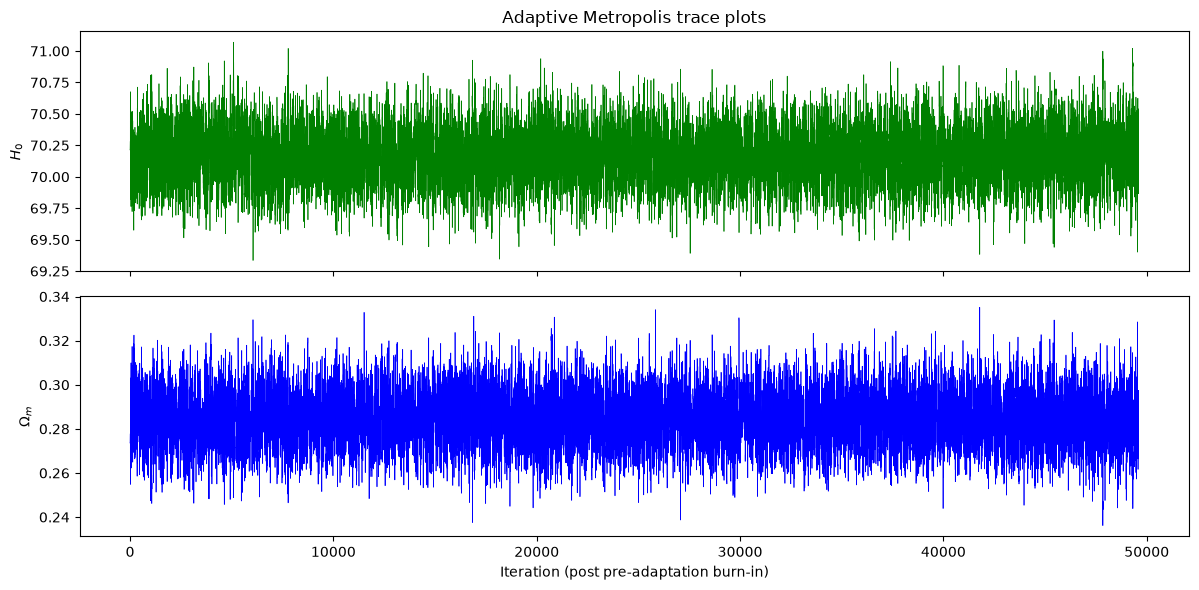

In [86]:
# trace plots
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(am_chain_trimmed['H0'], linewidth=0.5, color='green')
axes[0].set_ylabel('$H_0$')
axes[0].set_title('Adaptive Metropolis trace plots')

axes[1].plot(am_chain_trimmed['Omega_m'], linewidth=0.5, color='blue')
axes[1].set_ylabel('$\\Omega_m$')
axes[1].set_xlabel('Iteration (post pre-adaptation burn-in)')
plt.tight_layout()
plt.show()

## Covariance Evolution

The point of Adaptive Metropolis is that the proposal covariance itself is not fixed —
it's a moving target that tracks the chain's growing picture of the posterior. This plots
how the estimated $\Omega_m$-$H_0$ correlation and the proposal's step sizes changed at each
`adapt_interval` checkpoint, and compares the final adapted covariance to the pilot one.

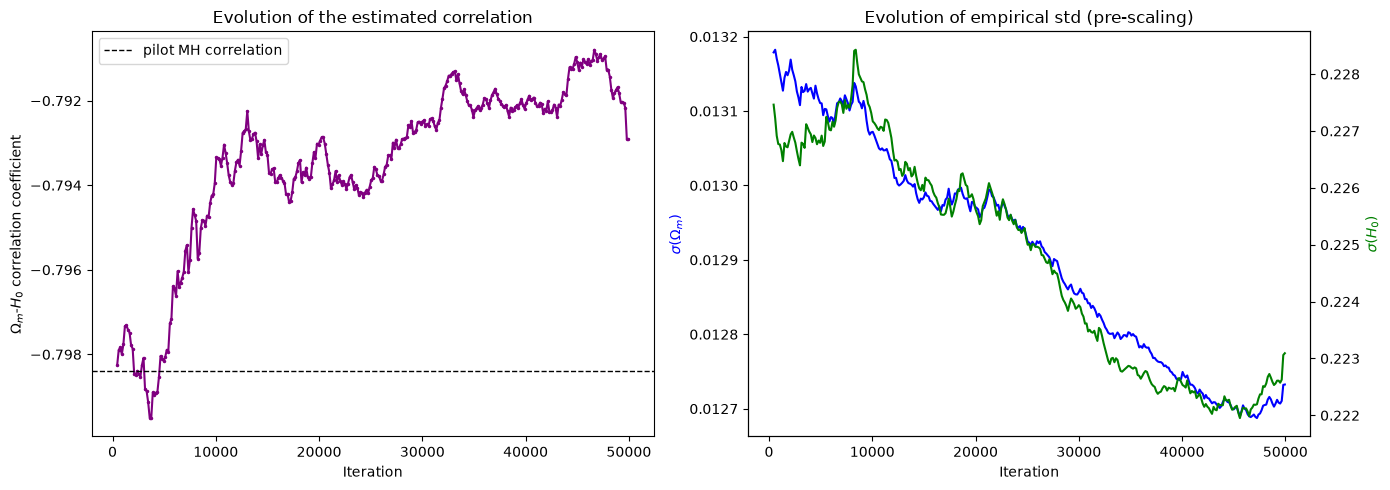

Pilot correlation:        -0.7984
Final adaptive correlation: -0.7929


In [87]:
# unpack the covariance snapshots recorded during the run
snap_iters = [s[0] for s in cov_snapshots]
snap_corr = [s[2] for s in cov_snapshots]
snap_std_omega_m = [np.sqrt(s[1][0, 0]) for s in cov_snapshots]
snap_std_H0 = [np.sqrt(s[1][1, 1]) for s in cov_snapshots]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(snap_iters, snap_corr, color='purple', marker='.', markersize=3)
axes[0].axhline(pilot_corr[0, 1], color='black', linestyle='--', linewidth=1, label='pilot MH correlation')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('$\\Omega_m$-$H_0$ correlation coefficient')
axes[0].set_title('Evolution of the estimated correlation')
axes[0].legend()

axes[1].plot(snap_iters, snap_std_omega_m, color='blue', label='$\\sigma(\\Omega_m)$ (empirical)')
ax2 = axes[1].twinx()
ax2.plot(snap_iters, snap_std_H0, color='green', label='$\\sigma(H_0)$ (empirical)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('$\\sigma(\\Omega_m)$', color='blue')
ax2.set_ylabel('$\\sigma(H_0)$', color='green')
axes[1].set_title('Evolution of empirical std (pre-scaling)')

plt.tight_layout()
plt.show()

print(f"Pilot correlation:        {pilot_corr[0, 1]:.4f}")
print(f"Final adaptive correlation: {snap_corr[-1]:.4f}")

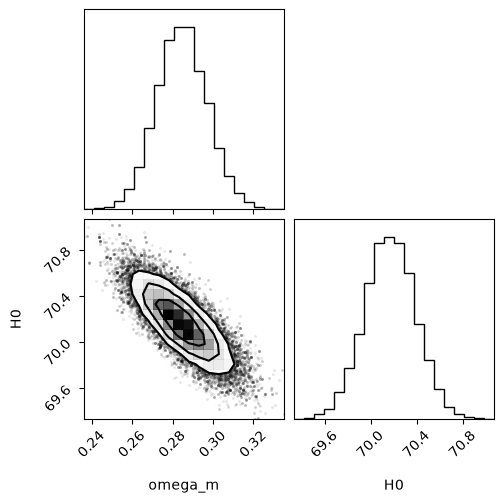

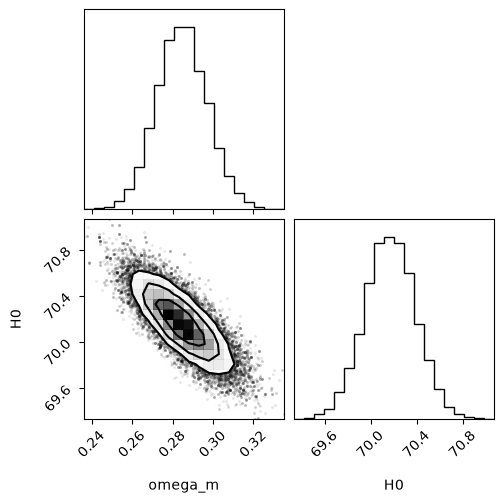

In [88]:
import corner

samples_dict = am_chain_trimmed[['Omega_m', 'H0']].to_numpy()   
corner.corner(samples_dict, labels=["omega_m", "H0"],)

# Comparison: MH vs emcee vs Adaptive Metropolis

Effective-sample counts below are computed the same way for **all three** chains this
time — via `emcee.autocorr.integrated_time` applied to each chain's own samples — rather
than using the raw accepted-sample count for the MH-style chains, which would overstate
how independent those samples actually are.

In [89]:
# properly-corrected effective sample sizes for the two random-walk-style chains
mh_tau = emcee.autocorr.integrated_time(mh_chain_trimmed[['Omega_m', 'H0']].to_numpy(), quiet=True)
mh_eff_samples_true = len(mh_chain_trimmed) / np.mean(mh_tau)

am_tau = emcee.autocorr.integrated_time(am_chain_trimmed[['Omega_m', 'H0']].to_numpy(), quiet=True)
am_eff_samples_true = len(am_chain_trimmed) / np.mean(am_tau)

am_accept_frac = n_accepted_am / am_n_iterations

print(f"MH autocorrelation time (omega_m, H0): {mh_tau}  ->  N_eff = {mh_eff_samples_true:.0f}")
print(f"AM autocorrelation time (omega_m, H0): {am_tau}  ->  N_eff = {am_eff_samples_true:.0f}")
print(f"emcee autocorrelation time (omega_m, H0): {emcee_tau}  ->  N_eff = {emcee_eff_samples:.0f}")

MH autocorrelation time (omega_m, H0): [29.4275024]  ->  N_eff = 917
AM autocorrelation time (omega_m, H0): [7.57657829]  ->  N_eff = 6546
emcee autocorrelation time (omega_m, H0): [30.95769685 28.79217861]  ->  N_eff = 1506


In [90]:
# three-way comparison table
three_way_table = pd.DataFrame({
    'Metric': [
        'H0 estimate (mean)',
        'H0 std',
        'Omega_m estimate (mean)',
        'Omega_m std',
        'Total samples drawn',
        'Acceptance fraction',
        'Autocorrelation time (avg)',
        'Effective independent samples',
        'N_eff per 1000 likelihood calls',
        'Proposal shape',
        'Needs manual tuning',
        'Parallelizable across chains',
        'Built-in convergence diagnostics',
    ],
    'Metropolis-Hastings': [
        f'{mh_mu_H0:.3f}', f'{mh_std_H0:.3f}',
        f'{mh_mu_omega_m:.4f}', f'{mh_std_omega_m:.4f}',
        mh_n_iterations, f'{mh_accept_frac:.3f}',
        f'{np.mean(mh_tau):.1f}', f'{mh_eff_samples_true:.0f}',
        f'{1000 * mh_eff_samples_true / mh_n_iterations:.2f}',
        'Fixed, diagonal (uncorrelated)', 'Yes (2 step sizes, bounds)',
        'No (single chain)', 'No (manual burn-in cut)',
    ],
    'emcee (ensemble)': [
        f'{emcee_mu_H0:.3f}', f'{emcee_std_H0:.3f}',
        f'{emcee_mu_omega_m:.4f}', f'{emcee_std_omega_m:.4f}',
        n_walkers * n_steps, f'{emcee_accept_frac:.3f}',
        f'{np.mean(emcee_tau):.1f}', f'{emcee_eff_samples:.0f}',
        f'{1000 * emcee_eff_samples / (n_walkers * n_steps):.2f}',
        'Self-tuning (ensemble spread)', 'No (self-tuning)',
        'Yes (walkers)', 'Yes (autocorr time tau)',
    ],
    'Adaptive Metropolis': [
        f'{am_mu_H0:.3f}', f'{am_std_H0:.3f}',
        f'{am_mu_omega_m:.4f}', f'{am_std_omega_m:.4f}',
        am_n_iterations, f'{am_accept_frac:.3f}',
        f'{np.mean(am_tau):.1f}', f'{am_eff_samples_true:.0f}',
        f'{1000 * am_eff_samples_true / am_n_iterations:.2f}',
        'Learned covariance (updates online)', 'Only initial seed (then self-tuning)',
        'No (single chain)', 'Partial (correlation/std evolution plot, no tau built in)',
    ],
})

three_way_table

,Metric,Metropolis-Hastings,emcee (ensemble),Adaptive Metropolis
0,H0 estimate (mean),70.159,70.156,70.168
1,H0 std,0.228,0.221,0.221
2,Omega_m estimate (mean),0.2851,0.2854,0.2846
3,Omega_m std,0.0132,0.0125,0.0125
4,Total samples drawn,50000,49500,50000
5,Acceptance fraction,0.541,0.712,0.345
6,Autocorrelation time (avg),29.4,29.9,7.6
7,Effective independent samples,917,1506,6546
8,N_eff per 1000 likelihood calls,18.33,30.43,130.93
9,Proposal shape,"Fixed, diagonal (uncorrelated)",Self-tuning (ensemble spread),Learned covariance (updates online)


**How to read the table:**

- **Estimate & std** should broadly agree across all three if each has converged — large disagreement is a red flag for one of them, not evidence the others are "more correct."
- **N_eff per 1000 likelihood calls** is the fairest efficiency comparison, since it normalizes out the fact that MH/AM make 1 likelihood call per iteration while emcee makes `n_walkers` calls per iteration. This is closer to "useful information per unit of compute" than either raw N_eff or raw sample count alone.
- **Adaptive Metropolis vs plain MH** isolates the effect of the covariance fix specifically: same basic algorithm, same accept/reject rule, only difference is whether the proposal shape matches the posterior's tilt. Any efficiency gain here is attributable to that alone, not to a different sampling paradigm (unlike the emcee comparison).
- **Adaptive Metropolis vs emcee** is the more interesting comparison: AM is a single chain that has to *learn* the covariance from its own trajectory (so it pays a "learning cost" early on), while emcee's ensemble effectively estimates local covariance for free from walker spread at every step. Expect AM to sit between plain MH and emcee in efficiency — better than a naive fixed-step chain, but still short of the ensemble sampler for a posterior with any nontrivial curvature (not just a simple tilt).

## Styled Posterior Corner Plots (2σ & 3σ contours only)

Separate corner plot per sampler, styled like a likelihood-contour figure: filled
2σ/3σ regions only (no 1σ, no raw scatter points, smoothed contours/marginals).
The original per-sampler corner plots earlier in the notebook are left as-is —
these are additional, differently-styled versions, one per method (not overlaid).

In [ ]:
# Metropolis-Hastings: 2-sigma/3-sigma styled corner plot
sigma_levels = (1 - np.exp(-0.5 * 2**2), 1 - np.exp(-0.5 * 3**2))  # 2-sigma, 3-sigma only

fig = corner.corner(
    mh_chain_trimmed[['Omega_m', 'H0']].to_numpy(),
    labels=['$\\Omega_m$', '$H_0$'],
    color='crimson',
    levels=sigma_levels,
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    smooth=1.5,
    smooth1d=1.5,
)
plt.suptitle('Metropolis-Hastings: 2\u03c3 & 3\u03c3 contours', y=1.02)
plt.show()


In [ ]:
# emcee: 2-sigma/3-sigma styled corner plot
sigma_levels = (1 - np.exp(-0.5 * 2**2), 1 - np.exp(-0.5 * 3**2))  # 2-sigma, 3-sigma only

fig = corner.corner(
    emcee_flat_samples[:, :2],
    labels=['$\\Omega_m$', '$H_0$'],
    color='royalblue',
    levels=sigma_levels,
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    smooth=1.5,
    smooth1d=1.5,
)
plt.suptitle('emcee: 2\u03c3 & 3\u03c3 contours', y=1.02)
plt.show()


In [ ]:
# Adaptive Metropolis: 2-sigma/3-sigma styled corner plot
sigma_levels = (1 - np.exp(-0.5 * 2**2), 1 - np.exp(-0.5 * 3**2))  # 2-sigma, 3-sigma only

fig = corner.corner(
    am_chain_trimmed[['Omega_m', 'H0']].to_numpy(),
    labels=['$\\Omega_m$', '$H_0$'],
    color='purple',
    levels=sigma_levels,
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    smooth=1.5,
    smooth1d=1.5,
)
plt.suptitle('Adaptive Metropolis: 2\u03c3 & 3\u03c3 contours', y=1.02)
plt.show()
